#   🚀 ¿Por qué se retrasan casi la mitad de los vuelos comerciales?
 ## Un análisis sobre +530,000 registros operativos.

El conjunto de datos de aerolíneas (*Airlines dataset*) contiene **539,383 instancias** y **8 características** diferentes. La tarea consiste en predecir si un vuelo determinado se retrasará, dada la información de la salida programada.

---

## Nombres de las características (*Features*)

1. **Airline** (Aerolínea)
2. **Flight** (Vuelo)
3. **Airport From** (Aeropuerto de origen)
4. **Airport To** (Aeropuerto de destino)
5. **DayOfWeek** (Día de la semana)
6. **Time** (Hora)
7. **Lenght** (Duracion del vuelo en minutos)
8. **Delay** (1 si está retrasado, 0 si no)

---

# Lista de Aerolíneas y Códigos IATA

| Código IATA | Aerolínea |
| :---: | :--- |
| **9E** | Endeavor Air (anteriormente Pinnacle Airlines) |
| **AA** | American Airlines |
| **AS** | Alaska Airlines |
| **B6** | JetBlue Airways |
| **CO** | Continental Airlines |
| **DL** | Delta Air Lines |
| **EV** | ExpressJet Airlines |
| **F9** | Frontier Airlines |
| **FL** | AirTran Airways |
| **HA** | Hawaiian Airlines |
| **MQ** | Envoy Air (anteriormente American Eagle) |
| **OH** | PSA Airlines |
| **OO** | SkyWest Airlines |
| **UA** | United Airlines |
| **US** | US Airways |
| **WN** | Southwest Airlines |
| **XE** | ExpressJet Airlines (código secundario / JetLink) |
| **YV** | Mesa Airlines |

---

## Aeropuertos

* **ATL** - Aeropuerto Internacional Hartsfield-Jackson de Atlanta - *Georgia*
* **AUS** - Aeropuerto Internacional de Austin-Bergstrom - *Texas*
* **BNA** - Aeropuerto Internacional de Nashville - *Tennessee*
* **BOS** - Aeropuerto Internacional Logan de Boston - *Massachusetts*
* **BWI** - Aeropuerto Internacional de Baltimore-Washington Thurgood Marshall - *Washington*
* **CLT** - Aeropuerto Internacional de Charlotte-Douglas - *Carolina del Norte*
* **DAL** - Campo Dallas Love - *Texas*
* **DCA** - Aeropuerto Nacional Ronald Reagan de Washington - *Arlington, Virginia*
* **DEN** - Aeropuerto Internacional de Denver - *Colorado*
* **DFW** - Aeropuerto Internacional de Dallas/Fort Worth - *Texas*
* **DTW** - Aeropuerto Metropolitano de Detroit - *Míchigan*
* **EWR** - Aeropuerto Internacional Libertad de Newark - *Nueva Jersey*
* **FLL** - Aeropuerto Internacional de Fort Lauderdale-Hollywood - *Florida*
* **HNL** - Aeropuerto Internacional Daniel K. Inouye - *Honolulú, Hawái*
* **HOU** - Aeropuerto William P. Hobby - *Houston, Texas*
* **IAD** - Aeropuerto Internacional de Dulles - *Virginia*
* **IAH** - Aeropuerto Intercontinental George Bush - *Houston, Texas*
* **JFK** - Aeropuerto Internacional John F. Kennedy - *Queens, Nueva York*
* **LAS** - Aeropuerto Internacional McCarran - *Las Vegas, Nevada*
* **LAX** - Aeropuerto Internacional de Los Ángeles - *California*
* **LGA** - Aeropuerto LaGuardia - *Queens, Nueva York*
* **MCO** - Aeropuerto Internacional de Orlando - *Florida*
* **MDW** - Aeropuerto Internacional Midway de Chicago - *Illinois*
* **MIA** - Aeropuerto Internacional de Miami - *Florida*
* **MSP** - Aeropuerto Internacional de Minneapolis-Saint Paul - *Minnesota*
* **MSY** - Aeropuerto Internacional Louis Armstrong de Nueva Orleans - *Luisiana*
* **OAK** - Aeropuerto Internacional de Oakland - *California*
* **ORD** - Aeropuerto Internacional O'Hare - *Chicago, Illinois*
* **PDX** - Aeropuerto Internacional de Portland - *Oregón*
* **PHL** - Aeropuerto Internacional de Filadelfia - *Pensilvania*
* **PHX** - Aeropuerto Internacional de Phoenix-Sky Harbor - *Arizona*
* **RDU** - Aeropuerto Internacional de Raleigh-Durham - *Carolina del Norte*
* **SAN** - Aeropuerto Internacional de San Diego - *California*
* **SEA** - Aeropuerto Internacional de Seattle-Tacoma - *Washington*
* **SFO** - Aeropuerto Internacional de San Francisco - *California*
* **SJC** - Aeropuerto Internacional Norman Y. Mineta de San José - *California*
* **SLC** - Aeropuerto Internacional de Salt Lake City - *Utah*
* **SMF** - Aeropuerto Internacional de Sacramento - *California*
* **STL** - Aeropuerto Internacional Lambert de San Luis - *Misuri*
* **TPA** - Aeropuerto Internacional de Tampa - *Florida*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [ ]:
#Convertimos los datos en un data frame para su analisis en pandas

df = pd.read_csv('Airlines.csv')
df.drop(['id'],axis=1,inplace=True)
df.head(10)

,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,CO,269,SFO,IAH,3,15,205,1
1,US,1558,PHX,CLT,3,15,222,1
2,AA,2400,LAX,DFW,3,20,165,1
3,AA,2466,SFO,DFW,3,20,195,1
4,AS,108,ANC,SEA,3,30,202,0
5,CO,1094,LAX,IAH,3,30,181,1
6,DL,1768,LAX,MSP,3,30,220,0
7,DL,2722,PHX,DTW,3,30,228,0
8,DL,2606,SFO,MSP,3,35,216,1
9,AA,2538,LAS,ORD,3,40,200,1


#Analísis Exploatorio


In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Flight,539383.0,2427.928630,2067.429837,1.0,712.0,1809.0,3745.0,7814.0
DayOfWeek,539383.0,3.929668,1.914664,1.0,2.0,4.0,5.0,7.0
Time,539383.0,802.728963,278.045911,10.0,565.0,795.0,1035.0,1439.0
Length,539383.0,132.202007,70.117016,0.0,81.0,115.0,162.0,655.0
Delay,539383.0,0.445442,0.497015,0.0,0.0,0.0,1.0,1.0


In [ ]:
unique_airlines = df['Airline'].unique()
display(unique_airlines)
len(unique_airlines)

array(['CO', 'US', 'AA', 'AS', 'DL', 'B6', 'HA', 'OO', '9E', 'OH', 'EV',
       'XE', 'YV', 'UA', 'MQ', 'FL', 'F9', 'WN'], dtype=object)

18

In [ ]:
unique_airports_from = df['AirportFrom'].unique()
len(unique_airports_from)

293

In [ ]:
unique_airports_to = df['AirportTo'].unique()
len(unique_airports_to)

293

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539383 entries, 0 to 539382
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Airline      539383 non-null  object
 1   Flight       539383 non-null  int64 
 2   AirportFrom  539383 non-null  object
 3   AirportTo    539383 non-null  object
 4   DayOfWeek    539383 non-null  int64 
 5   Time         539383 non-null  int64 
 6   Length       539383 non-null  int64 
 7   Delay        539383 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 32.9+ MB


In [ ]:
#Calculamos la matriz de correlacion de nuestras variables numericas
Airlinescorr=df[['Flight','DayOfWeek','Time','Length','Delay']].copy()
corrAirline=Airlinescorr.corr()
corr=px.imshow(corrAirline,text_auto=True)
corr.show()

#Insights


In [ ]:
#Las 5 aerolineas más impuntuales en promedio
top_5_unpunctual = ((df.groupby('Airline')['Delay'].mean().sort_values(ascending=False).head(5))*100).round(2)
display(top_5_unpunctual)

,Delay
Airline,
WN,69.78
CO,56.62
B6,46.70
OO,45.29
DL,45.05


In [ ]:
#Las 5 más puntuales en promedio
top_5_punctual = ((df.groupby('Airline')['Delay'].mean().sort_values(ascending=True).head(5))*100).round(2)
display(top_5_punctual)

,Delay
Airline,
YV,24.29
OH,27.73
FL,30.13
HA,32.02
UA,32.39


/tmp/ipykernel_4042/672824356.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




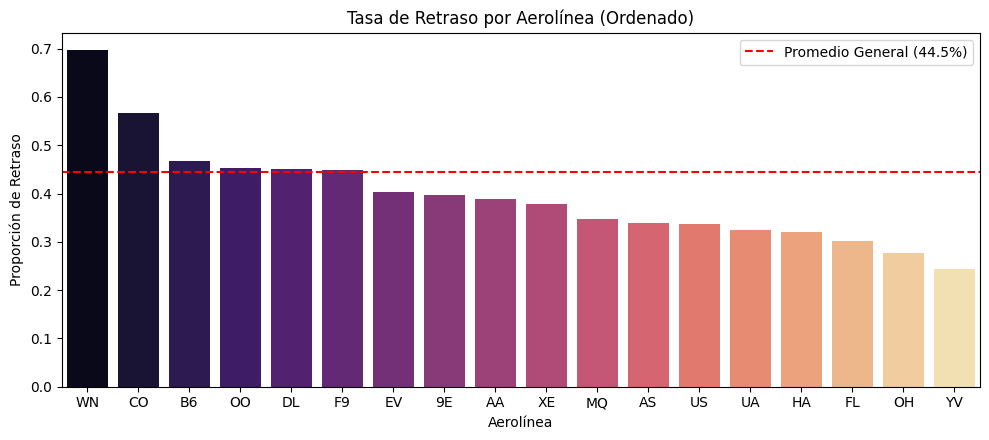

In [ ]:
#Graficamos las aerolineas de más a menos impuntual
plt.figure(figsize=(10, 4.5))
airline_order = df.groupby('Airline')['Delay'].mean().sort_values(ascending=False).index

sns.barplot(data=df, x='Airline', y='Delay', order=airline_order, errorbar=None, palette='magma')
plt.axhline(df['Delay'].mean(), color='red', linestyle='--', label=f'Promedio General ({df["Delay"].mean():.1%})')

plt.title('Tasa de Retraso por Aerolínea (Ordenado)')
plt.xlabel('Aerolínea')
plt.ylabel('Proporción de Retraso')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 1. Obtener la hora del día (0 a 23) a partir de los minutos acumulados
df['Hour'] = df['Time'] // 60

# 2. Agrupar por hora y calcular volumen de vuelos y tasa de retraso
efecto_hora = df.groupby('Hour')['Delay'].agg(
    total_vuelos='count',
    tasa_retraso='mean'
)

# Convertir la tasa a porcentaje para interpretación
efecto_hora['porcentaje_retraso'] = efecto_hora['tasa_retraso'] * 100
efecto_hora


,total_vuelos,tasa_retraso,porcentaje_retraso
Hour,,,
0,802,0.471322,47.132170
1,346,0.393064,39.306358
2,89,0.449438,44.943820
4,99,0.404040,40.404040
5,4840,0.233678,23.367769
6,38859,0.256697,25.669729
7,36847,0.302060,30.205987
8,37510,0.346494,34.649427
9,33622,0.404676,40.467551


In [ ]:
efecto_hora.describe()

,total_vuelos,tasa_retraso,porcentaje_retraso
count,23.000000,23.000000,23.000000
mean,23451.434783,0.438239,43.823868
std,15335.836942,0.085999,8.599903
min,89.000000,0.233678,23.367769
25%,6100.500000,0.404358,40.435796
50%,32762.000000,0.449438,44.943820
75%,34934.500000,0.507444,50.744376
max,38859.000000,0.542494,54.249389


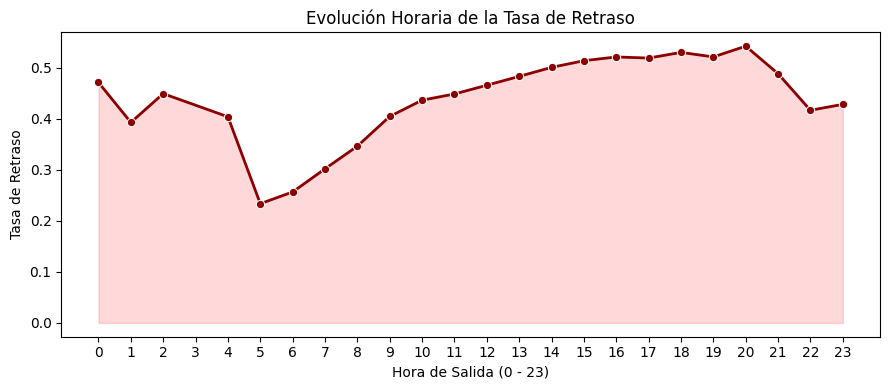

In [ ]:
plt.figure(figsize=(9, 4))
hourly = df.groupby('Hour')['Delay'].mean().reset_index()

sns.lineplot(data=hourly, x='Hour', y='Delay', marker='o', color='darkred', linewidth=2)
plt.fill_between(hourly['Hour'], hourly['Delay'], alpha=0.15, color='red')

plt.title('Evolución Horaria de la Tasa de Retraso')
plt.xlabel('Hora de Salida (0 - 23)')
plt.ylabel('Tasa de Retraso')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [ ]:
# Agrupar por el día de la semana (1 a 7)
efecto_dia = df.groupby('DayOfWeek')['Delay'].agg(
    total_vuelos='count',
    tasa_retraso='mean'
).reset_index()

# Convertir la tasa media a porcentaje
efecto_dia['porcentaje_retraso'] = efecto_dia['tasa_retraso'] * 100
efecto_dia

,DayOfWeek,total_vuelos,tasa_retraso,porcentaje_retraso
0,1,72769,0.467644,46.764419
1,2,71340,0.447337,44.733670
2,3,89746,0.470818,47.081764
3,4,91445,0.451025,45.102521
4,5,85248,0.416608,41.660801
5,6,58956,0.400553,40.055295
6,7,69879,0.453541,45.354112


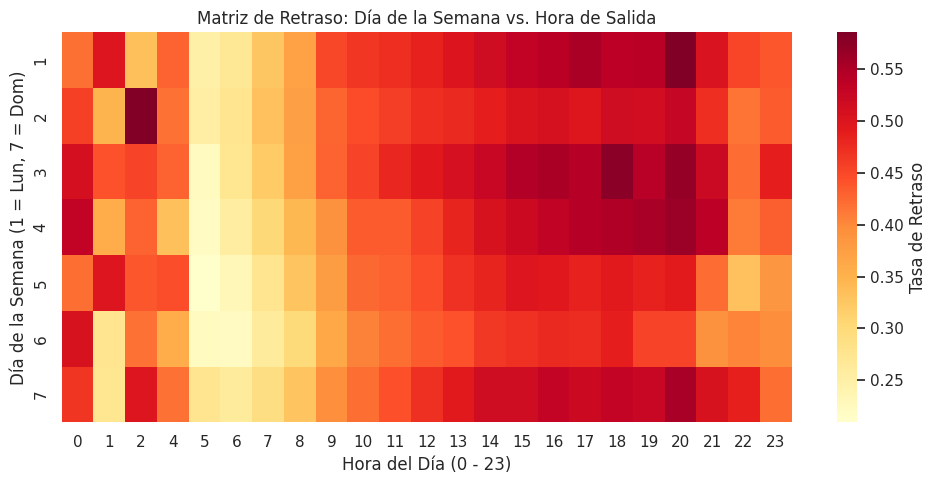

In [ ]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

pivot_tbl = df.pivot_table(index='DayOfWeek', columns='Hour', values='Delay', aggfunc='mean')
sns.heatmap(pivot_tbl, cmap='YlOrRd', cbar_kws={'label': 'Tasa de Retraso'})

plt.title('Matriz de Retraso: Día de la Semana vs. Hora de Salida')
plt.xlabel('Hora del Día (0 - 23)')
plt.ylabel('Día de la Semana (1 = Lun, 7 = Dom)')
plt.tight_layout()
plt.show()

In [ ]:
# 1. Agrupar la duración en 5 quintiles
df['Length_Group'] = pd.qcut(
    df['Length'],
    q=5,
    labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long']
)

# 2. Agrupar por categoría y calcular el volumen, rango y porcentaje de retraso
efecto_duracion = df.groupby('Length_Group', observed=False).agg(
    total_vuelos=('Delay', 'count'),
    tasa_retraso=('Delay', 'mean'),
    min_minutos=('Length', 'min'),
    max_minutos=('Length', 'max')
)

efecto_duracion['porcentaje_retraso'] = efecto_duracion['tasa_retraso'] * 100
efecto_duracion

,total_vuelos,tasa_retraso,min_minutos,max_minutos,porcentaje_retraso
Length_Group,,,,,
Very Short,108492,0.437682,0,75,43.768204
Short,109065,0.429487,76,100,42.948700
Medium,106862,0.427926,101,130,42.792574
Long,110131,0.440167,131,175,44.016671
Very Long,104833,0.493471,176,655,49.347057


/tmp/ipykernel_4042/3743807521.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




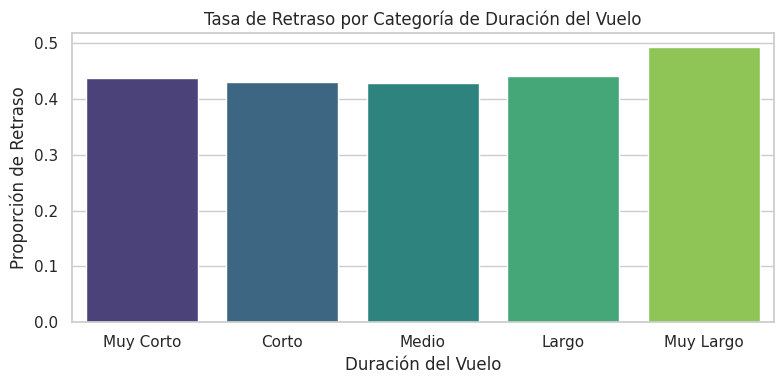

In [ ]:
df['Length_Group'] = pd.qcut(df['Length'], q=5, labels=['Muy Corto', 'Corto', 'Medio', 'Largo', 'Muy Largo'])

plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='Length_Group', y='Delay', errorbar=None, palette='viridis')

plt.title('Tasa de Retraso por Categoría de Duración del Vuelo')
plt.xlabel('Duración del Vuelo')
plt.ylabel('Proporción de Retraso')
plt.tight_layout()
plt.show()

In [ ]:
#Top 5 aeropuertos con más retrasos en promedio
top_5_aeropuertos_im = df.groupby("AirportFrom")["Delay"].mean().sort_values(ascending=False).head(5)*100
display(top_5_aeropuertos_im)

,Delay
AirportFrom,
MDW,73.518232
DAL,71.599792
OAK,71.292625
HOU,66.719457
OTH,63.440860


In [ ]:
#Top 5 aeropuertos con menos retrasos en promedio
top_5_aeropuertos_p = df.groupby("AirportFrom")["Delay"].mean().sort_values(ascending=True).head(5)*100
display(top_5_aeropuertos_p)

,Delay
AirportFrom,
TXK,11.688312
FLG,11.872146
HTS,12.280702
GTR,14.754098
TEX,14.814815


#Tratamiento de los datos

Editamos las comunas *Airline* y *DayOfweak* del data frame para facilitar el manejo y comprensión de los datos en un posterior archivo de power BI


In [ ]:
df.head()

,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay,Hour,Length_Group
0,CO,269,SFO,IAH,3,15,205,1,0,Muy Largo
1,US,1558,PHX,CLT,3,15,222,1,0,Muy Largo
2,AA,2400,LAX,DFW,3,20,165,1,0,Largo
3,AA,2466,SFO,DFW,3,20,195,1,0,Muy Largo
4,AS,108,ANC,SEA,3,30,202,0,0,Muy Largo


In [ ]:
df['DayOfWeek'] = df['DayOfWeek'].replace({1: 'Lunes', 2: 'Martes', 3: 'Miércoles', 4: 'Jueves', 5: 'Viernes', 6: 'Sábado', 7: 'Domingo'})
df['Airline'] = df['Airline'].replace({
    '9E': 'Endeavor Air',
    'AA': 'American Airlines',
    'AS': 'Alaska Airlines',
    'B6': 'JetBlue Airways',
    'CO': 'Continental Airlines',
    'DL': 'Delta Air Lines',
    'EV': 'ExpressJet Airlines',
    'F9': 'Frontier Airlines',
    'FL': 'AirTran Airways',
    'HA': 'Hawaiian Airlines',
    'MQ': 'Envoy Air',
    'OH': 'PSA Airlines',
    'OO': 'SkyWest Airlines',
    'UA': 'United Airlines',
    'US': 'US Airways',
    'WN': 'Southwest Airlines',
    'XE': 'ExpressJet Airlines (JetLink)',
    'YV': 'Mesa Airlines'
})
df.head()

,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay,Hour,Length_Group
0,Continental Airlines,269,SFO,IAH,Miércoles,15,205,1,0,Muy Largo
1,US Airways,1558,PHX,CLT,Miércoles,15,222,1,0,Muy Largo
2,American Airlines,2400,LAX,DFW,Miércoles,20,165,1,0,Largo
3,American Airlines,2466,SFO,DFW,Miércoles,20,195,1,0,Muy Largo
4,Alaska Airlines,108,ANC,SEA,Miércoles,30,202,0,0,Muy Largo


In [ ]:
#Descargamos nuestro nuevo df para compartilo con Power BI
df.to_csv('Airlines_clean.csv', index=False)